In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/repos_clean.csv")
df.head()

,repo_id,nombre,descripcion,lenguaje,stars,forks,topics,fecha_creacion,ultimo_commit,url,dias_sin_commit,antiguedad_dias,num_topics
0,287463830,microsoft/qlib,Qlib is an AI-oriented Quant investment platfo...,Python,41176,6490,"['quantitative-finance', 'machine-learning', '...",2020-08-14 06:46:00+00:00,2026-04-22 07:08:01+00:00,https://github.com/microsoft/qlib,1,2078,18
1,151619717,google-research/google-research,Google Research,Jupyter Notebook,37781,8395,"['machine-learning', 'ai', 'research']",2018-10-04 18:42:48+00:00,2026-04-23 17:29:59+00:00,https://github.com/google-research/google-rese...,0,2758,3
2,170544934,hudson-and-thames/mlfinlab,MlFinLab helps portfolio managers and traders ...,Python,4689,1249,"['machine-learning', 'trading', 'investing', '...",2019-02-13 16:57:25+00:00,2023-10-02 03:05:19+00:00,https://github.com/hudson-and-thames/mlfinlab,934,2626,11
3,145385156,catalyst-team/catalyst,Accelerated deep learning R&D,Python,3376,400,"['deep-learning', 'reinforcement-learning', 'm...",2018-08-20 07:56:13+00:00,2025-06-27 02:59:05+00:00,https://github.com/catalyst-team/catalyst,300,2803,20
4,100402731,ybayle/awesome-deep-learning-music,List of articles related to deep learning appl...,TeX,2957,342,"['awesome', 'awesome-list', 'unicorns', 'list'...",2017-08-15 17:36:33+00:00,2023-12-15 16:51:26+00:00,https://github.com/ybayle/awesome-deep-learnin...,860,3173,20


In [9]:
import os

os.makedirs("../reports", exist_ok=True)

A. Distribution of stars

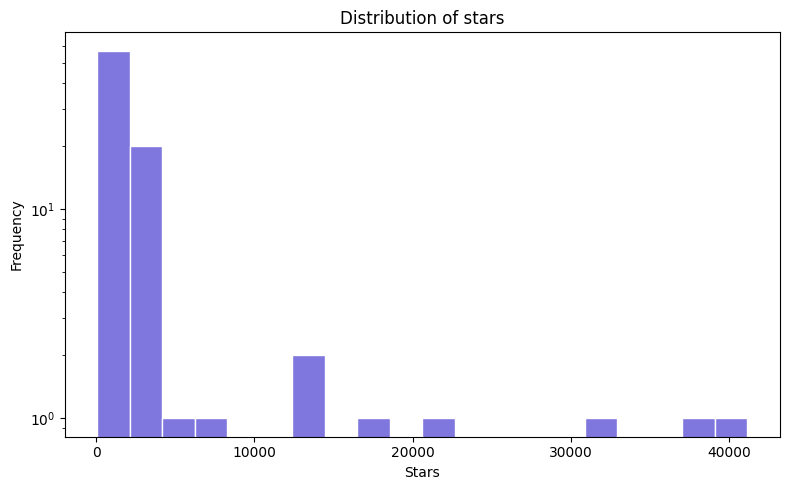

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["stars"], bins=20, log=True, color="#7F77DD", edgecolor="white")
plt.title("Distribution of stars")
plt.xlabel("Stars")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../reports/W3/EDA/distribution_stars.png", dpi=300, bbox_inches="tight")
plt.show()

B. Top programming languages

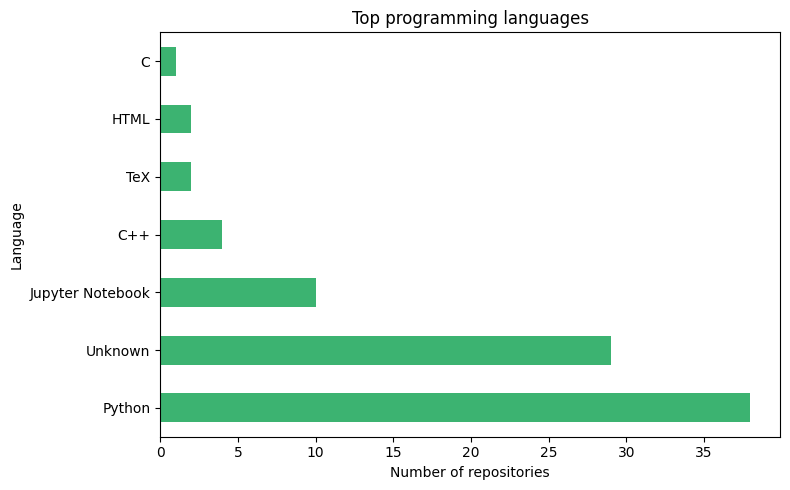

In [11]:
top_languages = df["lenguaje"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_languages.plot(kind="barh", color="mediumseagreen")
plt.title("Top programming languages")
plt.xlabel("Number of repositories")
plt.ylabel("Language")
plt.tight_layout()
plt.savefig("../reports/W3/EDA/top_languages.png", dpi=300, bbox_inches="tight")
plt.show()

C. Days since last commit

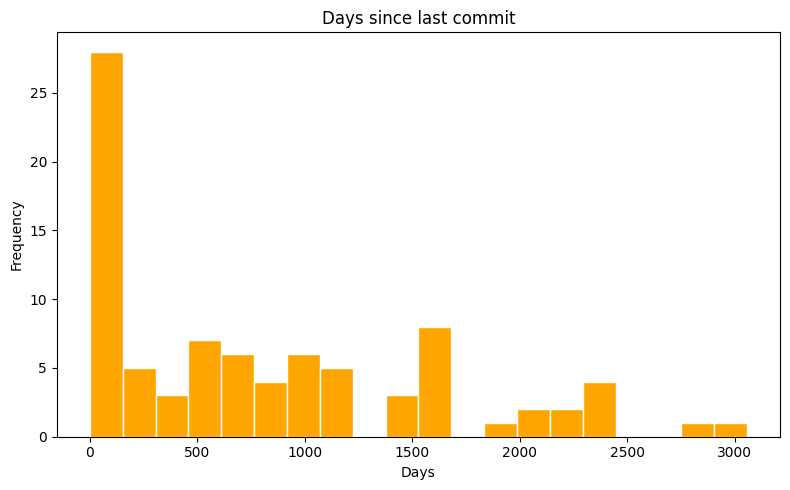

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["dias_sin_commit"], bins=20, color="orange" ,edgecolor="white")
plt.title("Days since last commit")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../reports/W3/EDA/days_since_last_commit.png", dpi=300, bbox_inches="tight")
plt.show()

D. Repository activity status

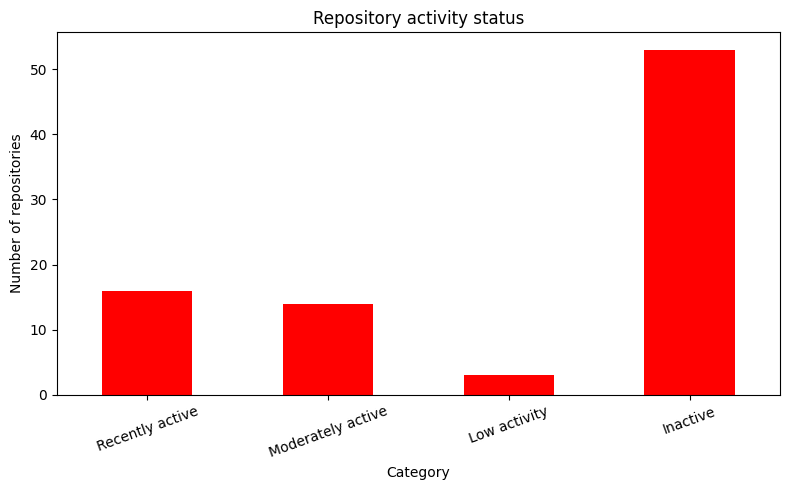

In [13]:
df["activity_status"] = pd.cut(
    df["dias_sin_commit"],
    bins=[-1, 30, 180, 365, 10000],
    labels=["Recently active", "Moderately active", "Low activity", "Inactive"]
)

activity_counts = df["activity_status"].value_counts().sort_index()

plt.figure(figsize=(8,5))
activity_counts.plot(kind="bar", color="red")
plt.title("Repository activity status")
plt.xlabel("Category")
plt.ylabel("Number of repositories")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../reports/W3/EDA/activity_status.png", dpi=300, bbox_inches="tight")
plt.show()

E. Repositories by creation year

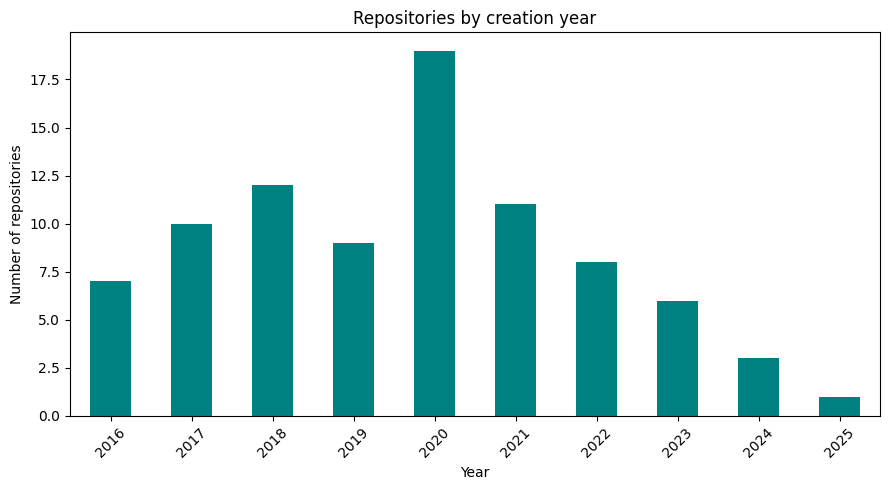

In [14]:
df["creation_year"] = pd.to_datetime(df["fecha_creacion"]).dt.year
year_counts = df["creation_year"].value_counts().sort_index()

plt.figure(figsize=(9,5))
year_counts.plot(kind="bar", color="teal")
plt.title("Repositories by creation year")
plt.xlabel("Year")
plt.ylabel("Number of repositories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/W3/EDA/creation_year.png", dpi=300, bbox_inches="tight")
plt.show()